In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvals
#from tqdm import tqdm

In [ ]:
# ----- build the weight matrix for analyzing M-WTA -----

def str_weight_matrix(M):
    
    W = np.full((M, M), "", dtype=object)

    # self excitation
    for i in range(M):
        W[i, i] += " + W1"

    # global inhibition among these neurons
    W += " - W2"
  
    # nearest-neighbor excitation (linear chain)
    for i in range(M - 1):
        W[i, i+1] += " + W3"
        W[i+1, i] += " + W3"
    
    return W

str_W = str_weight_matrix(4)
str_W

array([[' + W1 - W2', ' - W2 + W3', ' - W2', ' - W2'],
       [' - W2 + W3', ' + W1 - W2', ' - W2 + W3', ' - W2'],
       [' - W2', ' - W2 + W3', ' + W1 - W2', ' - W2 + W3'],
       [' - W2', ' - W2', ' - W2 + W3', ' + W1 - W2']], dtype=object)

In [ ]:
# ----- build the weight matrix for analyzing M-WTA -----

def weight_matrix(M, W1, W2, W3):
    
    W = np.zeros((M, M))
    
    # self excitation
    for i in range(M):
        W[i, i] += W1 
    
    # global inhibition among these neurons
    W -= W2
    
    # nearest-neighbor excitation (linear chain)
    for i in range(M - 1):
        W[i, i+1] += W3
        W[i+1, i] += W3
    
    return W

In [111]:
def test_check_MWTA_stability(M, W1, W2, W3, I_ext, tol=1e-12):

    W = weight_matrix(M, W1, W2, W3)

    # ----- Stablity Condition -----
    # Eigen values should be positive integers and maximum eigen value should be less than 1
    eigenvalues = np.linalg.eigvals(W)
    print ("eigenvalues: ", eigenvalues)

    # Check for complex numbers
    if not np.all(np.isreal(eigenvalues)):
        return False
        
    # Check for the upper bound (must be <= 1)
    if np.max(eigenvalues) >= 1:
        return False

    # ----- Consistency Condition -----
    # Consistency for M-WTA at steady state requires all x1,x2,...,xm > 0
    A = np.eye(M) - W
    b = I_ext * np.ones(M)

    try:
        x_s = np.linalg.solve(A, b)         
    except np.linalg.LinAlgError:
        return False 
    
    if np.min(x_s) <= 0:
        return False

    print ("x_s: ", x_s)

    # ---- Neighboring neurons suppresion condition ----
    # the neighboring neurons (left and right) of the active neurons are suppressed at steady state
    x_left = -W2*np.sum(x_s) + W3*x_s[0] + I_ext
    x_right = -W2*np.sum(x_s) + W3*x_s[-1] + I_ext
    print ("x_left: ", x_left)
    print ("x_right: ", x_right)

    if (x_right > 0) or (x_left > 0):
        return False
    

    return True

# check_MWTA_stability(M, W1, W2, W3, I_ext, tol=1e-12):
ok = test_check_MWTA_stability(2, 1, 1, 1, 0)
print("stable:", ok)

eigenvalues:  [0. 0.]
stable: False


In [145]:
def check_MWTA_stability(M, W1, W2, W3, I_ext, tol=1e-12):

    W = weight_matrix(M, W1, W2, W3)

    # ----- Consistency Condition -----
    # Consistency for M-WTA at steady state requires all x1,x2,...,xm > 0
    A = np.eye(M) - W
    b = I_ext * np.ones(M)
      
    try:
        x_s = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return False 
    
    if np.min(x_s) <= tol:
        return False

    # ---- Neighboring neurons suppresion condition ----
    # the neighboring neurons of the active neurons are suppressed (total inputs to these neurons are negative) at steady state
    x_left = -W2*np.sum(x_s) + W3*x_s[0] + I_ext
    x_right = -W2*np.sum(x_s) + W3*x_s[-1] + I_ext
    
    if (x_left > tol) or (x_right > tol) :
        return False
        
    # ----- Stablity Condition -----
    # Eigen values should be positive integers and maximum eigen value should be less than 1
    eigenvalues = np.linalg.eigvals(W)

    # Check for complex numbers
    if not np.all(np.isreal(eigenvalues)):
        return False
    
        
    # Check for the upper bound (must be <= 1)
    if np.max(eigenvalues) >= 1:
        return False


    return True

#       check_MWTA_stability(M, W1, W2, W3, I_ext, tol=1e-12):
M, W1, W2, W3, I_ext = 1, 0, 3, 1, 2
print("stable:", check_MWTA_stability(M, W1, W2, W3, I_ext))
print("-----")
print("stable:", test_check_MWTA_stability(M, W1, W2, W3, I_ext))
print("-----")
print("stable M+1:", check_MWTA_stability(M+1, W1, W2, W3, I_ext))


stable: False
-----
eigenvalues:  [-3.]
x_s:  [0.5]
x_left:  1.0
x_right:  1.0
stable: False
-----
stable M+1: False


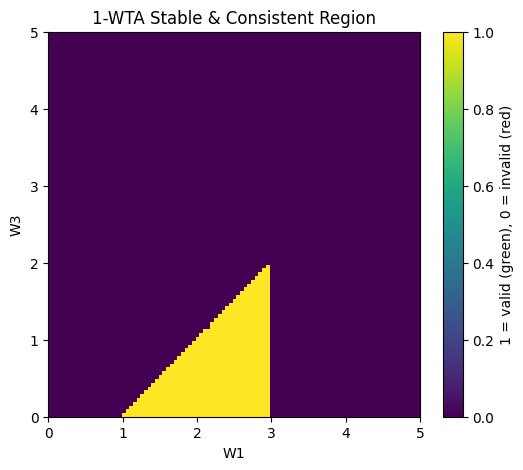

In [149]:
# Parameter grid
W1_vals = np.arange(0, 5.01, 0.05)
W3_vals = np.arange(0, 5.01, 0.05)

# values
M = 1
W1 = 2.0
W2 = 2.0
W3 = 1.0
I_ext = 2.0

phase = np.zeros((len(W1_vals), len(W3_vals)))

for i, W1 in enumerate(W1_vals):
    for j, W3 in enumerate(W3_vals):
        
        M_stable = check_MWTA_stability(M, W1, W2, W3, I_ext)
        M1_stable = check_MWTA_stability(M+1, W1, W2, W3, I_ext)
        
        # M-WTA is stable and (M+1)-WTA is unstable
        phase[i, j] = int(M_stable and not M1_stable)


# plot
plt.figure(figsize=(6,5))
plt.imshow(
    phase.T,
    extent=[0,5,0,5],
    origin='lower',
    aspect='auto'
)
plt.xlabel("W1")
plt.ylabel("W3")
plt.title(f"{M}-WTA Stable & Consistent Region")
plt.colorbar(label="1 = valid (green), 0 = invalid (red)")
plt.show()

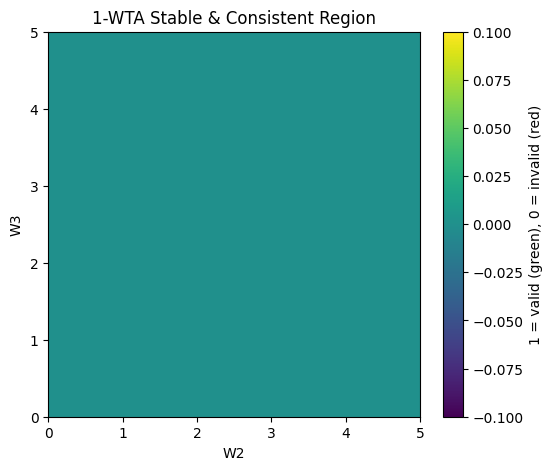

In [136]:
# Parameter grid
W2_vals = np.arange(0, 5.01, 0.01)
W3_vals = np.arange(0, 5.01, 0.01)

# values
M = 1
W1 = 0
W2 = 2.0
W3 = 1.0
I_ext = 2.0

phase = np.zeros((len(W2_vals), len(W3_vals)))

for i, W2 in enumerate(W2_vals):
    for j, W3 in enumerate(W3_vals):
        
        M_stable = check_MWTA_stability(M, W1, W2, W3, I_ext)
        M1_stable = check_MWTA_stability(M+1, W1, W2, W3, I_ext)
        
        # M-WTA is stable and (M+1)-WTA is unstable
        phase[i, j] = int(M_stable and not M1_stable)


# plot
plt.figure(figsize=(6,5))
plt.imshow(
    phase.T,
    extent=[0,5,0,5],
    origin='lower',
    aspect='auto'
)
plt.xlabel("W2")
plt.ylabel("W3")
plt.title(f"{M}-WTA Stable & Consistent Region")
plt.colorbar(label="1 = valid (green), 0 = invalid (red)")
plt.show()

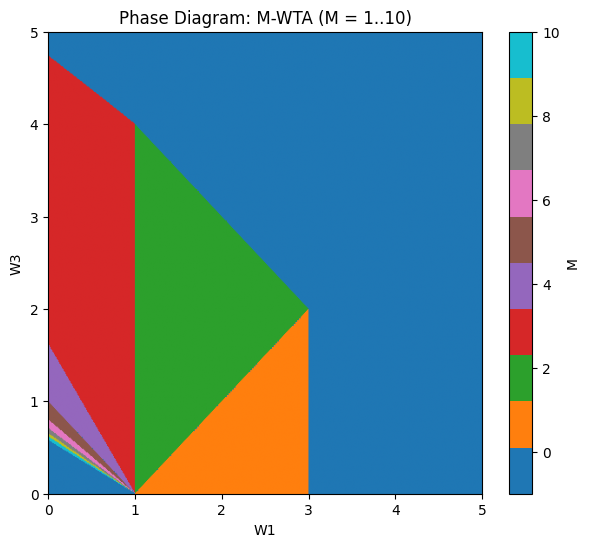

In [ ]:
# Parameter grid
W1_vals = np.arange(0, 5.01, 0.01)
W3_vals = np.arange(0, 5.01, 0.01)

W2 = 2.0
I_ext = 2.0

phase = np.zeros((len(W1_vals), len(W3_vals)))

for i, W1 in enumerate(W1_vals):
    for j, W3 in enumerate(W3_vals):

        for M in range(1, 11):

            M_stable  = check_MWTA_stability(M,   W1, W2, W3, I_ext)
            M1_stable = check_MWTA_stability(M+1, W1, W2, W3, I_ext)

            if M_stable and not M1_stable:
                phase[i, j] = M
                break   # stop once correct M is found



# plot
plt.figure(figsize=(7,6))
plt.imshow(
    phase.T,
    extent=[0,5,0,5],
    origin='lower',
    aspect='auto',
    cmap='tab10'
)
plt.xlabel("W1")
plt.ylabel("W3")
plt.title("Phase Diagram: M-WTA (M = 1..10)")
plt.colorbar(label="M")
plt.show()
